# 04 - Performance Analytics (Day 4)

Computes returns, risk metrics, and benchmarks.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sqlite3

# The heavy lifting is done in scripts/compute_metrics.py
# Let's load the generated metrics
metrics_file = Path('../outputs/performance_metrics.csv')
if metrics_file.exists():
    metrics = pd.read_csv(metrics_file)
    display(metrics.head())
else:
    print('Run scripts/compute_metrics.py first!')

,amfi_code,scheme_name,category,benchmark,return_1yr_pct,return_3yr_pct,benchmark_3yr_pct,return_5yr_pct,std_dev_ann_pct,sharpe_ratio,sortino_ratio,beta,alpha,r_squared,max_drawdown_pct,var_95_pct,cvar_95_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,NIFTY 100 TRI,60.437341,29.223656,8.401659,NaN,13.741434,1.208267,2.140267,-0.031751,23.201007,8.869789e-04,-15.012385,-1.284623,-1.639681
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,NIFTY 100 TRI,5.706100,15.643194,8.401659,NaN,13.939368,0.953279,1.609776,-0.026159,19.868599,5.850822e-04,-11.803494,-1.350097,-1.733570
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,BSE 250 SmallCap TRI,82.776059,25.604903,41.670024,NaN,25.140579,0.945308,1.675317,-0.047551,31.511086,1.753760e-03,-28.706006,-2.450705,-3.059526
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,BSE 250 SmallCap TRI,13.947803,-1.289932,41.670024,NaN,24.950125,-0.057187,-0.094387,0.011253,4.778436,9.972526e-05,-52.574221,-2.685944,-3.238412
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,CRISIL Dynamic Gilt Index,5.521996,5.626016,13.606038,NaN,3.967062,-0.226575,-0.376767,-0.000935,5.610709,9.468819e-07,-4.328729,-0.393828,-0.501369


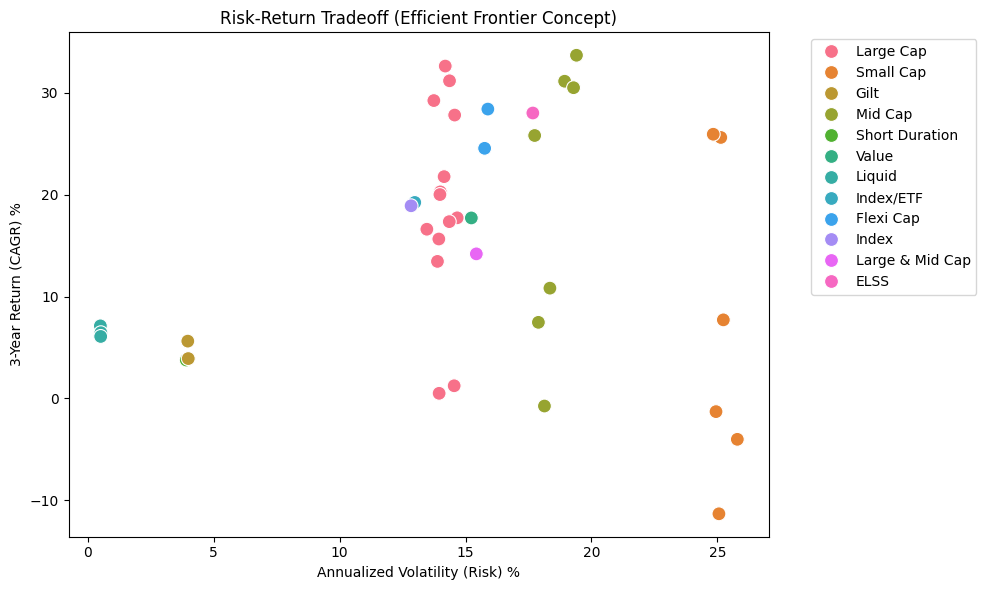

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

if metrics_file.exists():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=metrics, x='std_dev_ann_pct', y='return_3yr_pct', hue='category', s=100)
    plt.title('Risk-Return Tradeoff (Efficient Frontier Concept)')
    plt.xlabel('Annualized Volatility (Risk) %')
    plt.ylabel('3-Year Return (CAGR) %')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

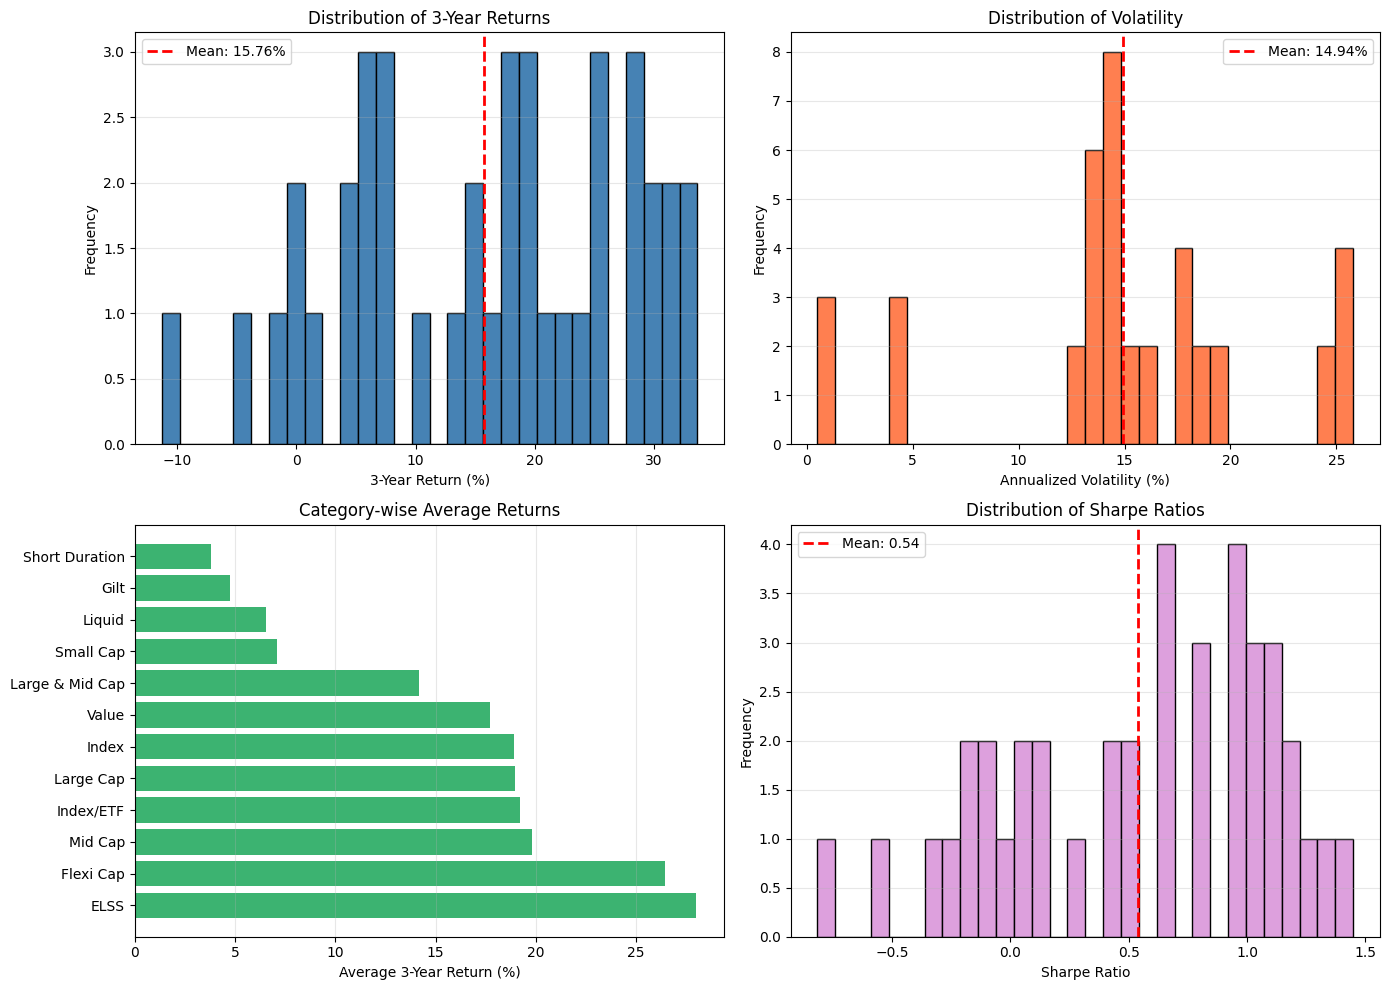

✅ Performance analytics visualizations completed


In [3]:
# Additional Performance Visualizations
if metrics_file.exists():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Returns distribution
    axes[0, 0].hist(metrics['return_3yr_pct'].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[0, 0].axvline(metrics['return_3yr_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {metrics['return_3yr_pct'].mean():.2f}%")
    axes[0, 0].set_xlabel('3-Year Return (%)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of 3-Year Returns')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Volatility distribution
    axes[0, 1].hist(metrics['std_dev_ann_pct'].dropna(), bins=30, color='coral', edgecolor='black')
    axes[0, 1].axvline(metrics['std_dev_ann_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {metrics['std_dev_ann_pct'].mean():.2f}%")
    axes[0, 1].set_xlabel('Annualized Volatility (%)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Volatility')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Category-wise average returns
    cat_returns = metrics.groupby('category')['return_3yr_pct'].mean().sort_values(ascending=False)
    axes[1, 0].barh(cat_returns.index, cat_returns.values, color='mediumseagreen')
    axes[1, 0].set_xlabel('Average 3-Year Return (%)')
    axes[1, 0].set_title('Category-wise Average Returns')
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # 4. Sharpe Ratio distribution (if available)
    if 'sharpe_ratio' in metrics.columns:
        sharpe_data = metrics['sharpe_ratio'].dropna()
        axes[1, 1].hist(sharpe_data, bins=30, color='plum', edgecolor='black')
        axes[1, 1].axvline(sharpe_data.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {sharpe_data.mean():.2f}")
        axes[1, 1].set_xlabel('Sharpe Ratio')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Distribution of Sharpe Ratios')
        axes[1, 1].legend()
        axes[1, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Performance analytics visualizations completed")